In [1]:
import numpy as np
import swarmData as swm
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','tomato']

%matplotlib inline

In [2]:
# refs = ['AlAminLucas1987','GoldenFisher1961','Kruithof1940','KucukarpaciLucas1981','MilloyCrompton1977','NakamuraKurachi1988','PackPhelps1961','Robertson1977','RobertsonRee1972','Specht1980','Tachibana1986']
refs = swm.swarmDatasets
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
    filename = '../swarm/%s.txt' % ref
    swarms.append( swm.swarmData(filename, convert=True) )
    print(swarms[idx].ref)
    for dataset in swarms[idx].datasets:
        for var, data in dataset.variables.items():
            print(var)
            print(data)
#         print(dataset.variables)
#         print(dataset.data)
    idx += 1


Al-Amin, S. A. J., & Lucas, J. (1987). Time of flight measurements of the ratio of radial diffusion coefficient and mobility for electron swarms in helium, argon, neon and krypton at high E/N. Journal of Physics D: Applied Physics, 20(12), 1590–1595. https://doi.org/10.1088/0022-3727/20/12/007
E/N
[  56.5   84.8  113.   141.   198.   254.   424.   565.   678.   848.
 1130.  1413.  1695.  1978.  2260.  2825.  3390.  4238.  5650. ]
DT/mu
[ 6.4   7.66  7.35  7.79  7.11  7.38  7.45  8.05  8.55  8.86 11.2  11.8
 13.   14.6  15.1  16.4  15.2  14.   12.8 ]
DT/mu-rms
[0.10666667 0.12766667 0.1225     0.12983333 0.1185     0.123
 0.12416667 0.13416667 0.1425     0.14766667 0.18666667 0.19666667
 0.21666667 0.24333333 0.25166667 0.27333333 0.25333333 0.23333333
 0.21333333]
Milloy, H. B., & Crompton, R. W. (1977). The Ratio of the Lateral Diffusion Coefficient to Mobility for Electrons in Argon at 294K. Australian Journal of Physics, 30, 51–60. http://www.publish.csiro.au/ph/pdf/PH770051
E/N
[0.

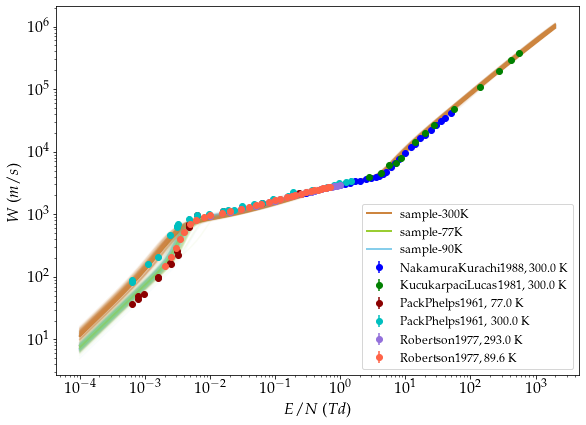

In [7]:
import input_writer as iw

var = 'W'

Nsample = 100

muN300 = np.fromfile('./forward-propagate/data-quartz6/transport300K.muN.dat')
N300 = iw.transport300K['RUNSERIES'][3]
E300 = np.linspace( np.log(iw.transport300K['RUNSERIES'][1]), np.log(iw.transport300K['RUNSERIES'][2]), N300)
E300 = np.exp(E300)
muN300 = np.reshape(muN300,[int(len(muN300)/N300),N300])
# print(muN300.shape, len(muN300))
inds_300 = np.random.randint(len(muN300), size=Nsample)

muN77 = np.fromfile('./forward-propagate/data-quartz6/transport77K.muN.dat')
N77 = iw.transport77K['RUNSERIES'][3]
E77 = np.linspace( np.log(iw.transport77K['RUNSERIES'][1]), np.log(iw.transport77K['RUNSERIES'][2]), N77)
E77 = np.exp(E77)
muN77 = np.reshape(muN77,[int(len(muN77)/N77),N77])
# print(muN300.shape, len(muN300))
inds_77 = np.random.randint(len(muN77), size=Nsample)

muN90 = np.fromfile('./forward-propagate/data-quartz6/transport90K.muN.dat')
N90 = iw.transport90K['RUNSERIES'][3]
E90 = np.linspace( np.log(iw.transport90K['RUNSERIES'][1]), np.log(iw.transport90K['RUNSERIES'][2]), N90)
E90 = np.exp(E90)
muN90 = np.reshape(muN90,[int(len(muN90)/N90),N90])
# print(muN300.shape, len(muN300))
inds_90 = np.random.randint(len(muN90), size=Nsample)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0
plt.figure(1)
for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if var in dataset.variables:
#             x = np.copy( dataset.variables['E/N'] )
#             y = np.copy( dataset.variables[var] )
#             yerr = np.copy( dataset.variables[var+'-rms'] )
#             plt.plot(dataset.variables['E/N'],
#                      dataset.variables[var] / dataset.variables['E/N'] * 1e21,
#                      '.',
#                      label='%s, %s K' % (refs[k], dataset.parameters['T']) )
            plt.errorbar(dataset.variables['E/N'],
                         dataset.variables[var],
                         yerr=dataset.variables[var+'-rms'],
                         fmt='o', color=colors[idx],
                         label='%s, %s K' % (refs[k], dataset.parameters['T']) )
            idx += 1
k = 0
muN300_sample = muN300[inds_300[k]]
plt.plot(E300,muN300_sample * E300 / swm.Td,'-', color='peru',linewidth=2.0,label='sample-300K')
muN77_sample = muN77[inds_77[k]]
plt.plot(E77, muN77_sample * E77 / swm.Td,'-',color='yellowgreen',linewidth=2.0,label='sample-77K')
muN90_sample = muN90[inds_90[k]]
plt.plot(E90, muN90_sample * E90 / swm.Td,'-',color='skyblue',linewidth=2.0,label='sample-90K')
for k in range(1,Nsample):
    muN300_sample = muN300[inds_300[k]]
    plt.plot(E300,muN300_sample * E300 / swm.Td,'-', color='peru',alpha=0.1)
    muN77_sample = muN77[inds_77[k]]
    plt.plot(E77, muN77_sample * E77 / swm.Td,'-',color='yellowgreen',alpha=0.05)
    muN90_sample = muN90[inds_90[k]]
    plt.plot(E90, muN90_sample * E90 / swm.Td,'-',color='skyblue',alpha=0.05)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$W$ ($m/s$)')
plt.tight_layout()
plt.legend(loc='lower right', prop={'size': 12})
fig = plt.gcf()
fig.set_size_inches(9, 7)

fig.savefig("./W.propagated.pdf", dpi=1200)

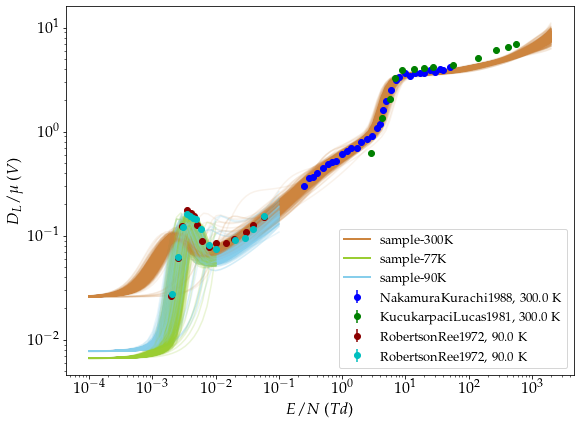

In [12]:
import input_writer as iw

var = 'DL/mu'
var1 = 'DLN'

Nsample = 1000

DLN300 = np.fromfile('./forward-propagate/data-quartz6/transport300K.DLN.dat')
N300 = iw.transport300K['RUNSERIES'][3]
E300 = np.linspace( np.log(iw.transport300K['RUNSERIES'][1]), np.log(iw.transport300K['RUNSERIES'][2]), N300)
E300 = np.exp(E300)
DLN300 = np.reshape(DLN300,[int(len(DLN300)/N300),N300])
muN300 = np.fromfile('./forward-propagate/data-quartz6/transport300K.muN.dat')
muN300 = np.reshape(muN300,[int(len(muN300)/N300),N300])
# print(muN300.shape, len(muN300))
inds_300 = np.random.randint(len(DLN300), size=Nsample)

DLN77 = np.fromfile('./forward-propagate/data-quartz6/transport77K.DLN.dat')
N77 = iw.transport77K['RUNSERIES'][3]
E77 = np.linspace( np.log(iw.transport77K['RUNSERIES'][1]), np.log(iw.transport77K['RUNSERIES'][2]), N77)
E77 = np.exp(E77)
DLN77 = np.reshape(DLN77,[int(len(DLN77)/N77),N77])
muN77 = np.fromfile('./forward-propagate/data-quartz6/transport77K.muN.dat')
muN77 = np.reshape(muN77,[int(len(muN77)/N77),N77])

# print(muN300.shape, len(muN300))
inds_77 = np.random.randint(len(DLN77), size=Nsample)

DLN90 = np.fromfile('./forward-propagate/data-quartz6/transport90K.DLN.dat')
N90 = iw.transport90K['RUNSERIES'][3]
E90 = np.linspace( np.log(iw.transport90K['RUNSERIES'][1]), np.log(iw.transport90K['RUNSERIES'][2]), N90)
E90 = np.exp(E90)
DLN90 = np.reshape(DLN90,[int(len(DLN90)/N90),N90])
muN90 = np.fromfile('./forward-propagate/data-quartz6/transport90K.muN.dat')
muN90 = np.reshape(muN90,[int(len(muN90)/N90),N90])
# print(muN300.shape, len(muN300))
inds_90 = np.random.randint(len(DLN90), size=Nsample)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0
plt.figure(1)
for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if var in dataset.variables:
#             x = np.copy( dataset.variables['E/N'] )
#             y = np.copy( dataset.variables[var] )
#             yerr = np.copy( dataset.variables[var+'-rms'] )
#             plt.plot(dataset.variables['E/N'],
#                      dataset.variables[var] / dataset.variables['E/N'] * 1e21,
#                      '.',
#                      label='%s, %s K' % (refs[k], dataset.parameters['T']) )
            plt.errorbar(dataset.variables['E/N'],
                         dataset.variables[var],
                         yerr=dataset.variables[var+'-rms'],
                         fmt='o', color=colors[idx],
                         label='%s, %s K' % (refs[k], dataset.parameters['T']) )
            idx += 1
        elif var1 in dataset.variables:
            plt.errorbar(dataset.variables['E/N'],
                         dataset.variables[var1] / dataset.variables['W'] * dataset.variables['E/N'] / swm.Td,
                         yerr=dataset.variables[var1+'-rms'] / dataset.variables['W'] * dataset.variables['E/N'] / swm.Td,
                         fmt='o', color=colors[idx],
                         label='%s, %s K' % (refs[k], dataset.parameters['T']) )
            idx += 1
            
k = 0
DLN300_sample = DLN300[inds_300[k]]
plt.plot(E300,DLN300_sample / muN300[inds_300[k]],'-', color='peru',linewidth=2.0,label='sample-300K')
DLN77_sample = DLN77[inds_77[k]]
plt.plot(E77, DLN77_sample / muN77[inds_77[k]],'-',color='yellowgreen',linewidth=2.0,label='sample-77K')
DLN90_sample = DLN90[inds_90[k]]
plt.plot(E90, DLN90_sample / muN90[inds_90[k]],'-',color='skyblue',linewidth=2.0,label='sample-90K')
for k in range(1,Nsample):
    DLN300_sample = DLN300[inds_300[k]]
    plt.plot(E300, DLN300_sample / muN300[inds_300[k]],'-', color='peru',alpha=0.1)
    DLN77_sample = DLN77[inds_77[k]]
    plt.plot(E77, DLN77_sample / muN77[inds_77[k]],'-',color='yellowgreen',alpha=0.2)
    DLN90_sample = DLN90[inds_90[k]]
    plt.plot(E90, DLN90_sample / muN90[inds_90[k]],'-',color='skyblue',alpha=0.2)
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$D_L/\mu$ ($V$)')
plt.tight_layout()
plt.legend(loc='lower right', prop={'size': 13})
fig = plt.gcf()
fig.set_size_inches(9, 7)

fig.savefig("./DLmu.propagated.pdf", dpi=1200)

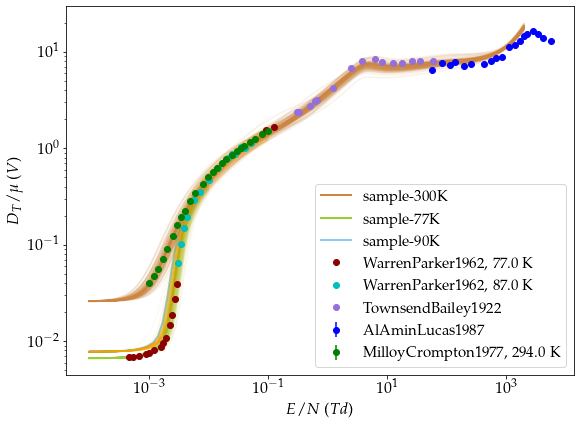

In [13]:
import input_writer as iw

var = 'DT/mu'
var1 = 'DTN'

Nsample = 100

DLN300 = np.fromfile('./forward-propagate/data-quartz6/transport300K.DTN.dat')
N300 = iw.transport300K['RUNSERIES'][3]
E300 = np.linspace( np.log(iw.transport300K['RUNSERIES'][1]), np.log(iw.transport300K['RUNSERIES'][2]), N300)
E300 = np.exp(E300)
DLN300 = np.reshape(DLN300,[int(len(DLN300)/N300),N300])
muN300 = np.fromfile('./forward-propagate/data-quartz6/transport300K.muN.dat')
muN300 = np.reshape(muN300,[int(len(muN300)/N300),N300])
# print(muN300.shape, len(muN300))
inds_300 = np.random.randint(len(DLN300), size=Nsample)

DLN77 = np.fromfile('./forward-propagate/data-quartz6/transport77K.DTN.dat')
N77 = iw.transport77K['RUNSERIES'][3]
E77 = np.linspace( np.log(iw.transport77K['RUNSERIES'][1]), np.log(iw.transport77K['RUNSERIES'][2]), N77)
E77 = np.exp(E77)
DLN77 = np.reshape(DLN77,[int(len(DLN77)/N77),N77])
muN77 = np.fromfile('./forward-propagate/data-quartz6/transport77K.muN.dat')
muN77 = np.reshape(muN77,[int(len(muN77)/N77),N77])

# print(muN300.shape, len(muN300))
inds_77 = np.random.randint(len(DLN77), size=Nsample)

DLN90 = np.fromfile('./forward-propagate/data-quartz6/transport90K.DTN.dat')
N90 = iw.transport90K['RUNSERIES'][3]
E90 = np.linspace( np.log(iw.transport90K['RUNSERIES'][1]), np.log(iw.transport90K['RUNSERIES'][2]), N90)
E90 = np.exp(E90)
DLN90 = np.reshape(DLN90,[int(len(DLN90)/N90),N90])
muN90 = np.fromfile('./forward-propagate/data-quartz6/transport90K.muN.dat')
muN90 = np.reshape(muN90,[int(len(muN90)/N90),N90])
# print(muN300.shape, len(muN300))
inds_90 = np.random.randint(len(DLN90), size=Nsample)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0
plt.figure(1)
k = 0
DLN300_sample = DLN300[inds_300[k]]
plt.plot(E300,DLN300_sample / muN300[inds_300[k]],'-', color='peru',linewidth=2.0,label='sample-300K')
DLN77_sample = DLN77[inds_77[k]]
plt.plot(E77, DLN77_sample / muN77[inds_77[k]],'-',color='yellowgreen',linewidth=2.0,label='sample-77K')
DLN90_sample = DLN90[inds_90[k]]
plt.plot(E90, DLN90_sample / muN90[inds_90[k]],'-',color='skyblue',linewidth=2.0,label='sample-90K')
for k in range(1,Nsample):
    DLN300_sample = DLN300[inds_300[k]]
    plt.plot(E300, DLN300_sample / muN300[inds_300[k]],'-', color='peru',alpha=0.1)
    DLN77_sample = DLN77[inds_77[k]]
    plt.plot(E77, DLN77_sample / muN77[inds_77[k]],'-',color='yellowgreen',alpha=0.05)
    DLN90_sample = DLN90[inds_90[k]]
    plt.plot(E90, DLN90_sample / muN90[inds_90[k]],'-',color='orange',alpha=0.05)
    
for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if 'T' in dataset.parameters:
            label = '%s, %s K' % (refs[k], dataset.parameters['T'])
        else:
            label = refs[k]
        if var in dataset.variables:
#             x = np.copy( dataset.variables['E/N'] )
#             y = np.copy( dataset.variables[var] )
#             yerr = np.copy( dataset.variables[var+'-rms'] )
#             plt.plot(dataset.variables['E/N'],
#                      dataset.variables[var] / dataset.variables['E/N'] * 1e21,
#                      '.',
#                      label='%s, %s K' % (refs[k], dataset.parameters['T']) )
            if var+'-rms' in dataset.variables:
                plt.errorbar(dataset.variables['E/N'],
                             dataset.variables[var],
                             yerr=dataset.variables[var+'-rms'],
                             fmt='o', color=colors[idx],
                             label=label )
            else:
                plt.plot(dataset.variables['E/N'],
                         dataset.variables[var],
                         'o', color=colors[idx],
                         label=label )
            idx += 1
        elif var1 in dataset.variables:
            plt.errorbar(dataset.variables['E/N'],
                         dataset.variables[var1] / dataset.variables['W'] * dataset.variables['E/N'] / swm.Td,
                         yerr=dataset.variables[var1+'-rms'] / dataset.variables['W'] * dataset.variables['E/N'] / swm.Td,
                         fmt='o', color=colors[idx],
                         label=label )
            idx += 1
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$D_T/\mu$ ($V$)')
plt.tight_layout()
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

fig.savefig("./DTmu.propagated.pdf", dpi=1200)

(7272, 50) 7272


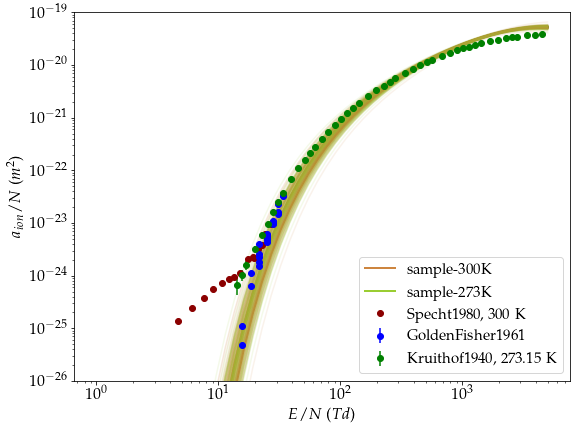

In [4]:
import input_writer as iw

var = 'a/N'
var1 = 'a/E'

Nsample = 100

DLN300 = np.fromfile('./forward-propagate/data-quartz6/rate300K.ion.dat')
N300 = iw.rate300K['RUNSERIES'][3]
E300 = np.linspace( np.log(iw.rate300K['RUNSERIES'][1]), np.log(iw.rate300K['RUNSERIES'][2]), N300)
E300 = np.exp(E300)
DLN300 = np.reshape(DLN300,[int(len(DLN300)/N300),N300])
muN300 = np.fromfile('./forward-propagate/data-quartz6/rate300K.muN.dat')
muN300 = np.reshape(muN300,[int(len(muN300)/N300),N300])
print(muN300.shape, len(muN300))
inds_300 = np.random.randint(len(DLN300), size=Nsample)

DLN273 = np.fromfile('./forward-propagate/data-quartz6/rate273K.ion.dat')
N273 = iw.rate273K['RUNSERIES'][3]
E273 = np.linspace( np.log(iw.rate273K['RUNSERIES'][1]), np.log(iw.rate273K['RUNSERIES'][2]), N273)
E273 = np.exp(E273)
DLN273 = np.reshape(DLN273,[int(len(DLN273)/N273),N273])
muN273 = np.fromfile('./forward-propagate/data-quartz6/rate273K.muN.dat')
muN273 = np.reshape(muN273,[int(len(muN273)/N273),N273])
inds_273 = np.random.randint(len(DLN273), size=Nsample)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0
plt.figure(1)
k = 0
DLN300_sample = DLN300[inds_300[k]]
plt.plot(E300,DLN300_sample / muN300[inds_300[k]] / E300 * swm.Td,'-', color='peru',linewidth=2.0,label='sample-300K')
DLN273_sample = DLN273[inds_273[k]]
plt.plot(E273,DLN273_sample / muN273[inds_273[k]] / E273 * swm.Td,'-', color='yellowgreen',linewidth=2.0,label='sample-273K')
for k in range(1,Nsample):
    DLN300_sample = DLN300[inds_300[k]]
    plt.plot(E300, DLN300_sample / muN300[inds_300[k]] / E300 * swm.Td,'-', color='peru',alpha=0.1)
    DLN273_sample = DLN273[inds_273[k]]
    plt.plot(E273,DLN273_sample / muN273[inds_273[k]] / E273 * swm.Td,'-', color='yellowgreen',alpha=0.1)
for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if 'T' in dataset.parameters:
            label = '%s, %s K' % (refs[k], dataset.parameters['T'])
        else:
            label = refs[k]
        if var in dataset.variables:
            if var+'-rms' in dataset.variables:
                plt.errorbar(dataset.variables['E/N'],
                             dataset.variables[var],
                             yerr=dataset.variables[var+'-rms'],
                             fmt='o', color=colors[idx],
                             label=label )
            else:
                plt.plot(dataset.variables['E/N'],
                         dataset.variables[var],
                         'o', color=colors[idx],
                         label=label )
            idx += 1
        elif var1 in dataset.variables:
            plt.errorbar(dataset.variables['E/N'],
                         dataset.variables[var1] * dataset.variables['E/N'] / swm.Td,
                         yerr=dataset.variables[var1+'-rms'] * dataset.variables['E/N'] / swm.Td,
                         fmt='o', color=colors[idx],
                         label=label )
            idx += 1
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$a_{ion}/N$ ($m^2$)')
plt.ylim([1e-26, 1e-19])
plt.tight_layout()
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

fig.savefig("./ion.propagated.pdf", dpi=1200)

In [6]:
print( 3.22e16 * 1e6 / 133.322 / swm.Td )

print( 100. / 133.322 * swm.kB * 300.0 * swm.Td )

0.24152052924498582
3.106723241475525


0 C2 Excitation 11.55
1 C3 Excitation 11.62
2 C4 Excitation 11.72
3 C5 Excitation 11.83
4 C6 Excitation 12.91
5 C7 Excitation 13.07
6 C8 Excitation 13.09
7 C9 Excitation 13.15
8 C10 Excitation 13.17
9 C11 Excitation 13.27
10 C12 Excitation 13.28
11 C13 Excitation 13.3
12 C14 Excitation 13.33
13 C15 Excitation 13.48
(1, 14, 40)
(7200, 14, 50)
(7200, 4, 50)
(7200, 50)
0


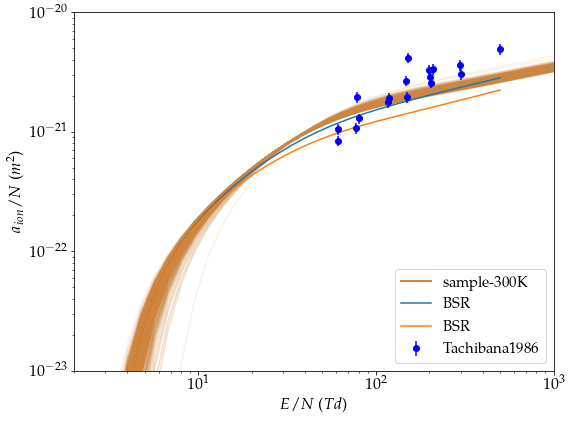

In [81]:
import input_writer as iw

var = 'a4/N'
var1 = 'a1/E'

paschen = {'1s5': 0, '1s4': 1, '1s3': 2, '1s2': 3,
           '2p10': 4, '2p9': 5, '2p8': 6, '2p7': 7, '2p6': 8, '2p5': 9, '2p4': 10, '2p3': 11, '2p2': 12, '2p1': 13 }
level = '1s2'

Akl = np.zeros([4,10])
Akl[0,:] = 1.0e8 * np.array([0.212, 0.366, 0.096, 0.057, 0.274, 0.0, 0.0065, 0.0395, 0.067, 0.0])
Akl[1,:] = 1.0e8 * np.array([0.060, 0.0, 0.233, 0.277, 0.0468, 0.430, 2.5e-4, 0.087, 0.02, 0.00241])
Akl[2,:] = 1.0e8 * np.array([0.0117, 0.0, 0.0, 0.028, 0.0, 0.0, 0.196, 0.0, 0.127, 0.0])
Akl[3,:] = 1.0e8 * np.array([0.0025, 0.0, 0.0161, 0.0115, 0.059, 0.0, 0.147, 0.244, 0.168, 0.472])

Nsample = 1000

from swarmParameters import bolsigOutput
outputFilename = "./forward-propagate/output/rate300K.ref.dat"
output = bolsigOutput(outputFilename)
mu = output.outputs[4].data[:,1]
nExcitation = 14
excitationTags = ['C%d' % (k+2) for k in range(nExcitation)]
rateExcite = np.zeros([nExcitation, N])
for ktag, tag in enumerate(excitationTags):
    dataType = output.typeDictS2I[tag]
    print(ktag, tag, output.outputs[dataType].collisionType, output.outputs[dataType].deltaE)
    rateExcite[ktag, :] = output.outputs[dataType].data[:,1]
    
aN = np.zeros([4,N])
for s in range(4):
    aN[s,:] = np.copy(rateExcite[s,:])
    for p in range(10):
        aN[s,:] += rateExcite[p+4,:] * Akl[s,p] / np.sum(Akl[:,p])

# for idx, table in output.outputs.items():
#     if ( (table.collisionType=='Excitation') and (table.deltaE>11.5) and (table.deltaE<11.6) ):
#         rate = np.copy(table.data[:,1])
N = 40
E = np.linspace( np.log(1.0), np.log(500.), N)
E = np.exp(E)

testExcite = np.fromfile('./forward-propagate/data/rate300K.excite.dat')
testExcite = np.reshape(testExcite,[int(len(testExcite)/14/N),14,N])
print(testExcite.shape)


# import input_writer as iw
N300 = iw.rate300K['RUNSERIES'][3]
# N300 = 40
# E300 = np.linspace( np.log(1.0), np.log(500.), N300)
E300 = np.linspace( np.log(iw.rate300K['RUNSERIES'][1]), np.log(iw.rate300K['RUNSERIES'][2]), N300)
E300 = np.exp(E300)

excite300 = np.fromfile('./forward-propagate/data-quartz3/rate300K.excite.dat')
excite300 = np.reshape(excite300,[int(len(excite300)/14/N300),14,N300])
print(excite300.shape)
aN300 = np.zeros([excite300.shape[0],4,N300])
print(aN300.shape)
for s in range(4):
    aN300[:,s,:] = np.copy(excite300[:,s,:])
    for p in range(10):
        aN300[:,s,:] += excite300[:,p+4,:] * Akl[s,p] / np.sum(Akl[:,p])

DLN300 = np.fromfile('./forward-propagate/data-quartz3/rate300K.1s4.dat')
DLN300 = np.reshape(DLN300,[int(len(DLN300)/N300),N300])
print(DLN300.shape)
muN300 = np.fromfile('./forward-propagate/data-quartz3/rate300K.muN.dat')
muN300 = np.reshape(muN300,[int(len(muN300)/N300),N300])
# print(muN300.shape, len(muN300))
inds_300 = np.random.randint(len(DLN300), size=Nsample)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0

k = 0
aN300_sample = aN300[inds_300[k],paschen[level],:]
plt.plot(E300,aN300_sample / muN300[inds_300[k]] / E300 * swm.Td,'-', color='peru',linewidth=2.0,label='sample-300K')
for k in range(1,Nsample):
    aN300_sample = aN300[inds_300[k],paschen[level],:]
    plt.plot(E300, aN300_sample / muN300[inds_300[k]] / E300 * swm.Td,'-', color='peru',alpha=0.1)
plt.plot(E, aN[paschen[level],:] / (mu * E / swm.Td), '-',label='BSR')
plt.plot(E, rateExcite[paschen[level],:] / (mu * E / swm.Td), '-',label='BSR')
# plt.plot(E300, excite300[0,0,:] / (muN300[0] * E300 / swm.Td), '-')
# for k in range(4,14):
#     plt.plot(E300, excite300[0,k,:] / (muN300[0] * E300 / swm.Td), '-')
for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if 'T' in dataset.parameters:
            label = '%s, %s K' % (refs[k], dataset.parameters['T'])
        else:
            label = refs[k]
        if var in dataset.variables:
            print(idx)
            if var+'-rms' in dataset.variables:
                plt.errorbar(dataset.variables['E/N'],
                             dataset.variables[var],
                             yerr=dataset.variables[var+'-rms'],
#                              yerr=dataset.variables[var] * 0.5,
                             fmt='o', color=colors[idx],
                             label=label )
            else:
                plt.plot(dataset.variables['E/N'],
                         dataset.variables[var],
                         'o', color=colors[idx],
                         label=label )
            idx += 1
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$a_{ion}/N$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([2, 1000])
plt.tight_layout()
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

# fig.savefig("./1s5.propagated.pdf", dpi=1200)

621.0117239273421
0


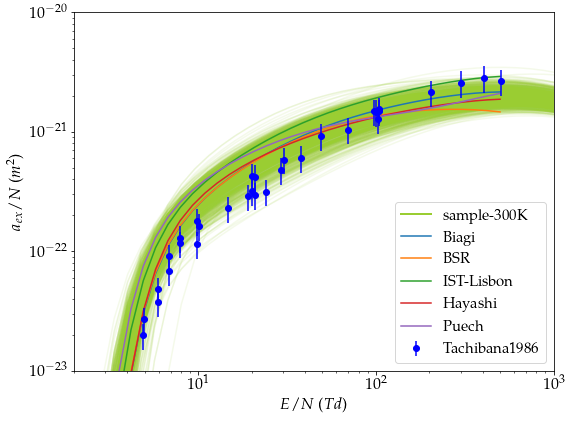

In [44]:
import input_writer as iw
from swarmParameters import bolsigOutput

Nsample = 1000

levelidx = 1
var = 'a%d/N' % levelidx

paschen = {'1s5': 0, '1s4': 1, '1s3': 2, '1s2': 3,
           '2p10': 4, '2p9': 5, '2p8': 6, '2p7': 7, '2p6': 8, '2p5': 9, '2p4': 10, '2p3': 11, '2p2': 12, '2p1': 13 }
level = '1s%d' % (6 - levelidx)

Akl = np.zeros([4,10])
Akl[0,:] = 1.0e8 * np.array([0.212, 0.366, 0.096, 0.057, 0.274, 0.0, 0.0065, 0.0395, 0.067, 0.0])
Akl[1,:] = 1.0e8 * np.array([0.060, 0.0, 0.233, 0.277, 0.0468, 0.430, 2.5e-4, 0.087, 0.02, 0.00241])
Akl[2,:] = 1.0e8 * np.array([0.0117, 0.0, 0.0, 0.028, 0.0, 0.0, 0.196, 0.0, 0.127, 0.0])
Akl[3,:] = 1.0e8 * np.array([0.0025, 0.0, 0.0161, 0.0115, 0.059, 0.0, 0.147, 0.244, 0.168, 0.472])

nExcitation = 14
excitationTags = ['C%d' % (k+2) for k in range(nExcitation)]

# import input_writer as iw
N300 = iw.rate300K['RUNSERIES'][3]
E300 = np.linspace( np.log(iw.rate300K['RUNSERIES'][1]), np.log(iw.rate300K['RUNSERIES'][2]), N300)
E300 = np.exp(E300)
print(E300[-13])
excite300 = np.fromfile('./forward-propagate/data-quartz5/rate300K.excite.dat')
excite300 = np.reshape(excite300,[int(len(excite300)/14/N300),14,N300])
aN300 = np.zeros([excite300.shape[0],4,N300])
for s in range(4):
    aN300[:,s,:] = np.copy(excite300[:,s,:])
    for p in range(10):
        aN300[:,s,:] += excite300[:,p+4,:] * Akl[s,p] / np.sum(Akl[:,p])
muN300 = np.fromfile('./forward-propagate/data-quartz5/rate300K.muN.dat')
muN300 = np.reshape(muN300,[int(len(muN300)/N300),N300])
inds_300 = np.random.randint(len(muN300), size=Nsample)

# for k in range(excite300.shape[0]):
# #     print(aN300[k,0,13] / muN300[k,13] / E300[13] * swm.Td)
# #     if (aN300[k,0,13] / muN300[k,13] / E300[13] * swm.Td > 2e-22):
#     if (aN300[k,0,-13] / muN300[k,-13] / E300[-13] * swm.Td < 1e-21):
#         aN300[k,0,:] *= 0.0

N = 40
E = np.linspace( np.log(1.0), np.log(500.), N)
E = np.exp(E)

muSets, aNSets = [], []
datasets = ['Biagi','BSR','IST-Lisbon','Hayashi','Puech']

for dataset in datasets:
    outputFilename = "./output/datasets/%s-rate.dat" % dataset
    output = bolsigOutput(outputFilename)
    mu = output.outputs[4].data[:,1]
    rateExcite = np.zeros([nExcitation, N])
    for ktag, tag in enumerate(excitationTags):
        dataType = output.typeDictS2I[tag]
    #     print(ktag, tag, output.outputs[dataType].collisionType, output.outputs[dataType].deltaE)
        rateExcite[ktag, :] = output.outputs[dataType].data[:,1]

    aN = np.zeros([4,N])
    for s in range(4):
        aN[s,:] = np.copy(rateExcite[s,:])
        for p in range(10):
            aN[s,:] += rateExcite[p+4,:] * Akl[s,p] / np.sum(Akl[:,p])
            
    muSets += [np.copy(mu)]
    aNSets += [np.copy(aN)]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0

for k in range(Nsample):
    aN300_sample = aN300[inds_300[k],paschen[level],:]
    if (aN300_sample[-13] / muN300[inds_300[k],-13] / E300[-13] * swm.Td > 1e-21):
#     if (aN300_sample[13] / muN300[inds_300[k],13] / E300[13] * swm.Td > 2.5e-22):
        colork = 'yellowgreen'
    else:
#         colork = 'darkviolet'
        colork = 'yellowgreen'
    if (k==0):
        plt.plot(E300,aN300_sample / muN300[inds_300[k]] / E300 * swm.Td,'-', color=colork,linewidth=2.0,label='sample-300K')
    else:
        plt.plot(E300, aN300_sample / muN300[inds_300[k]] / E300 * swm.Td,'-', color=colork,alpha=0.1)

for k, dataset in enumerate(datasets):
    plt.plot(E, aNSets[k][paschen[level],:] / (muSets[k] * E / swm.Td), '-',label=dataset)
# plt.plot(E, rateExcite[paschen[level],:] / (mu * E / swm.Td), '-',label='BSR')
for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if 'T' in dataset.parameters:
            label = '%s, %s K' % (refs[k], dataset.parameters['T'])
        else:
            label = refs[k]
        if var in dataset.variables:
            print(idx)
            if var+'-rms' in dataset.variables:
                plt.errorbar(dataset.variables['E/N'],
                             dataset.variables[var],
                             yerr=dataset.variables[var+'-rms'] * 3.0,
#                              yerr=dataset.variables[var] * 0.5,
                             fmt='o', color=colors[idx],
                             label=label )
            else:
                plt.plot(dataset.variables['E/N'],
                         dataset.variables[var],
                         'o', color=colors[idx],
                         label=label )
            idx += 1
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$a_{ex}/N$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([2, 1000])
plt.tight_layout()
# plt.legend(loc='upper left', prop={'size': 15})
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

# fig.savefig("./1s%d.propagated.1.all_sample.pdf" % (6-levelidx), dpi=1200)

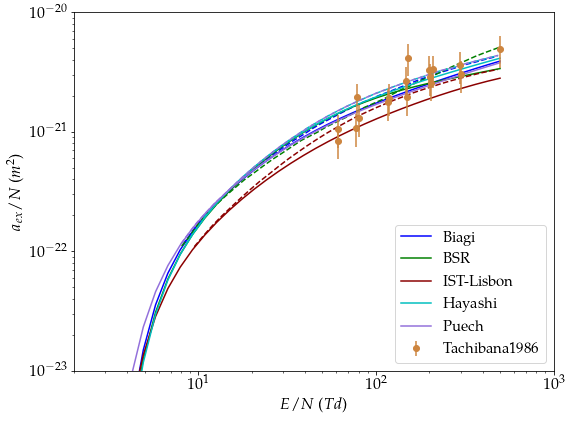

In [7]:
import input_writer as iw
from swarmParameters import bolsigOutput

Nsample = 500

levelidx = 4

var = 'a%d/N' % (levelidx)

paschen = {'1s5': 0, '1s4': 1, '1s3': 2, '1s2': 3,
           '2p10': 4, '2p9': 5, '2p8': 6, '2p7': 7, '2p6': 8, '2p5': 9, '2p4': 10, '2p3': 11, '2p2': 12, '2p1': 13 }
level = '1s%d' % (6 - levelidx)

Akl = np.zeros([4,10])
# Akl[0,:] = 1.0e8 * np.array([0.212, 0.366, 0.096, 0.057, 0.274, 0.0, 0.0065, 0.0395, 0.067, 0.0])
# Akl[1,:] = 1.0e8 * np.array([0.060, 0.0, 0.233, 0.277, 0.0468, 0.430, 2.5e-4, 0.087, 0.02, 0.00241])
# Akl[2,:] = 1.0e8 * np.array([0.0117, 0.0, 0.0, 0.028, 0.0, 0.0, 0.196, 0.0, 0.127, 0.0])
# Akl[3,:] = 1.0e8 * np.array([0.0025, 0.0, 0.0161, 0.0115, 0.059, 0.0, 0.147, 0.244, 0.168, 0.472])
Akl[0,:] = np.array([0.760, 1.180, 0.363, 0.075, 0.738, 0.0, 0.039, 0.118, 0.136, 0.0])
Akl[1,:] = np.array([0.215, 0.0, 0.640, 0.241, 0.2,     0.538, 0.039 * 2.5e-4 / 6.5e-3, 0.306, 0.001, 0.01])
Akl[2,:] = np.array([0.042, 0.0, 0.0, 0.045, 0.0,       0.0, 0.334, 0.0, 0.149, 0.0])
Akl[3,:] = np.array([0.008, 0.0, 0.053, 0.014, 0.206,   0.0, 0.509, 0.568, 0.171, 1.0])


nExcitation = 14
excitationTags = ['C%d' % (k+2) for k in range(nExcitation)]

N = 40
E = np.linspace( np.log(1.0), np.log(500.), N)
E = np.exp(E)

muSets, aNSets = [], []
aSets, vSets = [], []
rateExciteSets = []
pitchFord = []
datasets = ['Biagi','BSR','IST-Lisbon','Hayashi','Puech']
# datasets = ['Biagi','Biagi-reverse']
# datasets = ['BSR','BSR-reverse']
# datasets = ['Hayashi']

for dataset in datasets:
#     outputFilename = "./output/datasets/%s-rate.cascade.dat" % dataset
    outputFilename = "./output/datasets/%s-rate.dat" % dataset
    output = bolsigOutput(outputFilename)
    mu = output.outputs[4].data[:,1]
    aa = output.outputs[11].data[:,1]
    vv = output.outputs[10].data[:,1]
    rateExcite = np.zeros([nExcitation, N])
    for ktag, tag in enumerate(excitationTags):
        dataType = output.typeDictS2I[tag]
    #     print(ktag, tag, output.outputs[dataType].collisionType, output.outputs[dataType].deltaE)
        rateExcite[ktag, :] = output.outputs[dataType].data[:,1]
    rateExciteSets += [np.copy(rateExcite)]

    aN = np.zeros([4,N])
    for s in range(4):
        aN[s,:] = np.copy(rateExcite[s,:])
        for p in range(10):
            aN[s,:] += rateExcite[p+4,:] * Akl[s,p] / np.sum(Akl[:,p])
#             aN[s,:] += 0.25 * rateExcite[p+4,:]
            
    muSets += [np.copy(mu)]
    aNSets += [np.copy(aN)]
    
    aSets += [np.copy(aa)]
    vSets += [np.copy(vv)]
    
    if(dataset[-8:]!='-reverse'):
        pitchFord += [np.loadtxt("./output/datasets/%s-rate.Pitchford.%s.dat" % (dataset, level))]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0
for k, dataset in enumerate(datasets):
    plt.plot(E, aNSets[k][paschen[level],:] / (muSets[k] * E / swm.Td), '-',label=dataset, color=colors[idx])
#     plt.plot(E, aNSets[k][paschen[level],:] * aSets[k] / vSets[k], '-',label=dataset, color=colors[idx])
#     plt.plot(E, rateExciteSets[k][paschen[level],:] / (muSets[k] * E / swm.Td), '-',label=dataset, color=colors[idx])
    if(dataset[-8:]!='-reverse'):
        plt.plot(pitchFord[k][:,0], pitchFord[k][:,1], '--', color = colors[idx])
    idx += 1
    
#     for p in range(10):
#         plt.plot(E, rateExciteSets[k][p+4,:] / (muSets[k] * E / swm.Td), '-.')

for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if 'T' in dataset.parameters:
            label = '%s, %s K' % (refs[k], dataset.parameters['T'])
        else:
            label = refs[k]
        if var in dataset.variables:
            if var+'-rms' in dataset.variables:
                plt.errorbar(dataset.variables['E/N'],
                             dataset.variables[var],
                             yerr=dataset.variables[var+'-rms']*3.0,
#                              yerr=dataset.variables[var] * 0.1,
                             fmt='o', color='peru',
                             label=label )
            else:
                plt.plot(dataset.variables['E/N'],
                         dataset.variables[var],
                         'o', color='peru',
                         label=label )
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$a_{ex}/N$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([2, 1000])
plt.tight_layout()
# plt.legend(loc='upper left', prop={'size': 15})
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

# fig.savefig("./%s.Pitchford.1.pdf" % level, dpi=1200)

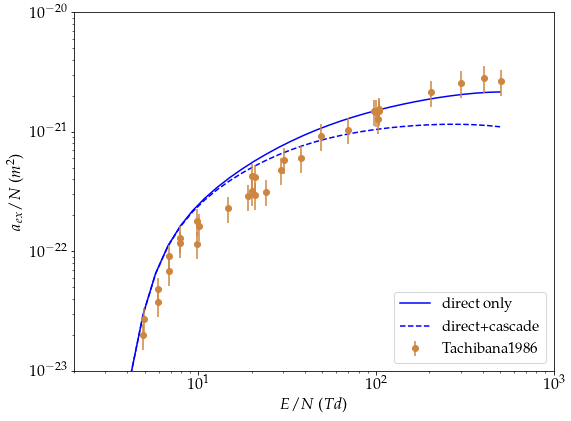

In [12]:
import input_writer as iw
from swarmParameters import bolsigOutput

Nsample = 500

levelidx = 1

var = 'a%d/N' % (levelidx)

paschen = {'1s5': 0, '1s4': 1, '1s3': 2, '1s2': 3,
           '2p10': 4, '2p9': 5, '2p8': 6, '2p7': 7, '2p6': 8, '2p5': 9, '2p4': 10, '2p3': 11, '2p2': 12, '2p1': 13 }
level = '1s%d' % (6 - levelidx)

Akl = np.zeros([4,10])
Akl[0,:] = 1.0e8 * np.array([0.212, 0.366, 0.096, 0.057, 0.274, 0.0, 0.0065, 0.0395, 0.067, 0.0])
Akl[1,:] = 1.0e8 * np.array([0.060, 0.0, 0.233, 0.277, 0.0468, 0.430, 2.5e-4, 0.087, 0.02, 0.00241])
Akl[2,:] = 1.0e8 * np.array([0.0117, 0.0, 0.0, 0.028, 0.0, 0.0, 0.196, 0.0, 0.127, 0.0])
Akl[3,:] = 1.0e8 * np.array([0.0025, 0.0, 0.0161, 0.0115, 0.059, 0.0, 0.147, 0.244, 0.168, 0.472])


nExcitation = 14
excitationTags = ['C%d' % (k+2) for k in range(nExcitation)]

N = 40
E = np.linspace( np.log(1.0), np.log(500.), N)
E = np.exp(E)

muSets, aNSets = [], []
aSets, vSets = [], []
rateExciteSets = []
pitchFord = []
datasets = ['Biagi']
# datasets = ['Biagi','Biagi-reverse']
# datasets = ['BSR','BSR-reverse']
# datasets = ['Hayashi']

for dataset in datasets:
#     outputFilename = "./output/datasets/%s-rate.cascade.dat" % dataset
    outputFilename = "./output/datasets/%s-rate.dat" % dataset
    output = bolsigOutput(outputFilename)
    mu = output.outputs[4].data[:,1]
    aa = output.outputs[11].data[:,1]
    vv = output.outputs[10].data[:,1]
    rateExcite = np.zeros([nExcitation, N])
    for ktag, tag in enumerate(excitationTags):
        dataType = output.typeDictS2I[tag]
    #     print(ktag, tag, output.outputs[dataType].collisionType, output.outputs[dataType].deltaE)
        rateExcite[ktag, :] = output.outputs[dataType].data[:,1]
    rateExciteSets += [np.copy(rateExcite)]

    aN = np.zeros([4,N])
    for s in range(4):
        aN[s,:] = np.copy(rateExcite[s,:])
        for p in range(10):
            aN[s,:] += rateExcite[p+4,:] * Akl[s,p] / np.sum(Akl[:,p])
#             aN[s,:] += 0.25 * rateExcite[p+4,:]
            
    muSets += [np.copy(mu)]
    aNSets += [np.copy(aN)]
    
    aSets += [np.copy(aa)]
    vSets += [np.copy(vv)]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0
for k, dataset in enumerate(datasets):
    plt.plot(E, aNSets[k][paschen[level],:] / (muSets[k] * E / swm.Td), '-',label="direct only", color=colors[idx])
    plt.plot(E, rateExciteSets[k][paschen[level],:] / (muSets[k] * E / swm.Td), '--',label="direct+cascade", color=colors[idx])
    idx += 1

for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if 'T' in dataset.parameters:
            label = '%s, %s K' % (refs[k], dataset.parameters['T'])
        else:
            label = refs[k]
        if var in dataset.variables:
            if var+'-rms' in dataset.variables:
                plt.errorbar(dataset.variables['E/N'],
                             dataset.variables[var],
                             yerr=dataset.variables[var+'-rms']*3.0,
#                              yerr=dataset.variables[var] * 0.1,
                             fmt='o', color='peru',
                             label=label )
            else:
                plt.plot(dataset.variables['E/N'],
                         dataset.variables[var],
                         'o', color='peru',
                         label=label )
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$a_{ex}/N$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([2, 1000])
plt.tight_layout()
# plt.legend(loc='upper left', prop={'size': 15})
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

fig.savefig("./%s.cascade.pdf" % level, dpi=1200)

11.549 ,  11.549
11.624 ,  11.624
11.723 ,  11.723
11.828 ,  11.828


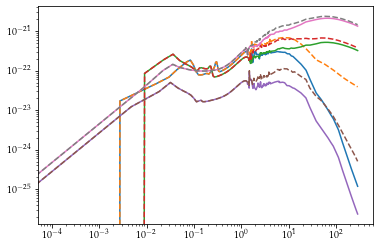

In [12]:
import crossSections as cross
import models

filename = "./crs/BSR.txt"
refcrs = cross.multipleCrossSections(filename)
filename = "./crs/BSR.cascade.txt"
testcrs = cross.multipleCrossSections(filename)

plt.figure(1)
for k in range(1,5):
    print(refcrs.crs[k].deltaE, ", ", testcrs.crs[k].deltaE)
    plt.loglog(refcrs.crs[k].data[:,0]-models.E_ext[k-1],refcrs.crs[k].data[:,1],'-')
    plt.loglog(testcrs.crs[k].data[:,0]-models.E_ext[k-1],testcrs.crs[k].data[:,1],'--')

0


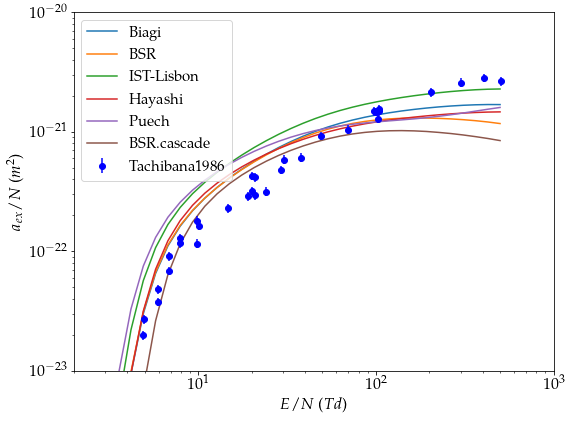

In [18]:
import input_writer as iw
from swarmParameters import bolsigOutput

var = 'a1/N'

paschen = {'1s5': 0, '1s4': 1, '1s3': 2, '1s2': 3,
           '2p10': 4, '2p9': 5, '2p8': 6, '2p7': 7, '2p6': 8, '2p5': 9, '2p4': 10, '2p3': 11, '2p2': 12, '2p1': 13 }
level = '1s5'

Akl = np.zeros([4,10])
Akl[0,:] = 1.0e8 * np.array([0.212, 0.366, 0.096, 0.057, 0.274, 0.0, 0.0065, 0.0395, 0.067, 0.0])
Akl[1,:] = 1.0e8 * np.array([0.060, 0.0, 0.233, 0.277, 0.0468, 0.430, 2.5e-4, 0.087, 0.02, 0.00241])
Akl[2,:] = 1.0e8 * np.array([0.0117, 0.0, 0.0, 0.028, 0.0, 0.0, 0.196, 0.0, 0.127, 0.0])
Akl[3,:] = 1.0e8 * np.array([0.0025, 0.0, 0.0161, 0.0115, 0.059, 0.0, 0.147, 0.244, 0.168, 0.472])

nExcitation = 14
excitationTags = ['C%d' % (k+2) for k in range(nExcitation)]

N = 40
E = np.linspace( np.log(1.0), np.log(500.), N)
E = np.exp(E)

muSets, aNSets = [], []
datasets = ['Biagi','BSR','IST-Lisbon','Hayashi','Puech']

for dataset in datasets:
    outputFilename = "./output/datasets/%s-rate.dat" % dataset
    output = bolsigOutput(outputFilename)
    mu = output.outputs[4].data[:,1]
    rateExcite = np.zeros([nExcitation, N])
    for ktag, tag in enumerate(excitationTags):
        dataType = output.typeDictS2I[tag]
    #     print(ktag, tag, output.outputs[dataType].collisionType, output.outputs[dataType].deltaE)
        rateExcite[ktag, :] = output.outputs[dataType].data[:,1]

    aN = np.zeros([4,N])
    for s in range(4):
        aN[s,:] = np.copy(rateExcite[s,:])
        for p in range(10):
            aN[s,:] += rateExcite[p+4,:] * Akl[s,p] / np.sum(Akl[:,p])
            
    muSets += [np.copy(mu)]
    aNSets += [np.copy(aN)]
    
outputFilename = "./output/datasets/BSR-rate.cascade.dat"
output = bolsigOutput(outputFilename)
muTest = output.outputs[4].data[:,1]
rateExcite = np.zeros([nExcitation, N])
for ktag, tag in enumerate(excitationTags):
    dataType = output.typeDictS2I[tag]
#     print(ktag, tag, output.outputs[dataType].collisionType, output.outputs[dataType].deltaE)
    rateExcite[ktag, :] = output.outputs[dataType].data[:,1]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0

for k, dataset in enumerate(datasets):
    plt.plot(E, aNSets[k][paschen[level],:] / (muSets[k] * E / swm.Td), '-',label=dataset)
plt.plot(E, rateExcite[paschen[level],:] / (muTest * E / swm.Td), '-',label='BSR.cascade')
for k, swarm in enumerate(swarms):
    for dataset in swarm.datasets:
        if 'T' in dataset.parameters:
            label = '%s, %s K' % (refs[k], dataset.parameters['T'])
        else:
            label = refs[k]
        if var in dataset.variables:
            print(idx)
            if var+'-rms' in dataset.variables:
                plt.errorbar(dataset.variables['E/N'],
                             dataset.variables[var],
                             yerr=dataset.variables[var+'-rms'],
#                              yerr=dataset.variables[var] * 0.5,
                             fmt='o', color=colors[idx],
                             label=label )
            else:
                plt.plot(dataset.variables['E/N'],
                         dataset.variables[var],
                         'o', color=colors[idx],
                         label=label )
            idx += 1
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('$a_{ex}/N$ ($m^2$)')
plt.ylim([1e-23, 1e-20])
plt.xlim([2, 1000])
plt.tight_layout()
plt.legend(loc='upper left', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

# fig.savefig("./1s3.Biagi.propagated.pdf", dpi=1200)

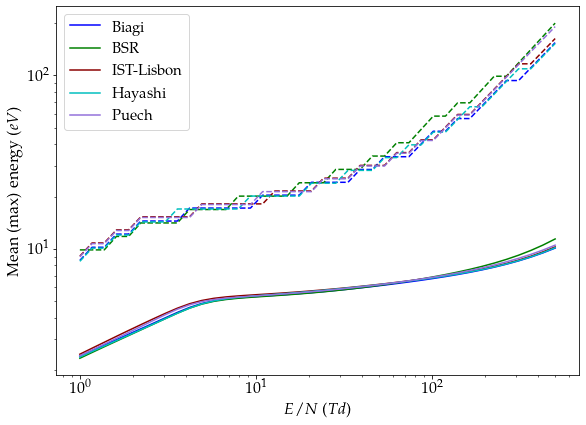

In [21]:
import input_writer as iw
from swarmParameters import bolsigOutput

Nsample = 500

N = 40
E = np.linspace( np.log(1.0), np.log(500.), N)
E = np.exp(E)

maxE, meanE = [], []
datasets = ['Biagi','BSR','IST-Lisbon','Hayashi','Puech']
# datasets = ['Hayashi']

for dataset in datasets:
    outputFilename = "./output/datasets/%s-rate.dat" % dataset
    output = bolsigOutput(outputFilename)
    
    maxE += [np.copy(output.outputs[2].data[:,1])]
    meanE += [np.copy(output.outputs[3].data[:,1])]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

idx = 0
for k, dataset in enumerate(datasets):
    plt.plot(E, maxE[k], '--', color=colors[idx])
    plt.plot(E, meanE[k], '-', label=dataset, color=colors[idx])
    idx += 1
            
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E/N$ ($Td$)')
plt.ylabel('Mean (max) energy ($eV$)')
# plt.ylim([1e-23, 1e-20])
# plt.xlim([2, 1000])
plt.tight_layout()
plt.legend(loc='upper left', prop={'size': 15})
# plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(9, 7)

# fig.savefig("./mean_energy.pdf", dpi=1200)

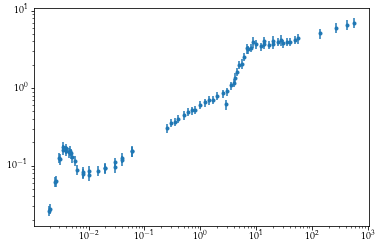

In [9]:
temp = np.copy(swarms[3].datasets[0].data)
error = temp[:,1][...,None] * 0.15
DLmu = np.append( temp, error, axis=1 )

filename = '../swarm/DLmu.%s.txt' % refs[3]
np.savetxt(filename,DLmu,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[5].datasets[0].data)
temp[:,1] = temp[:,2]/(temp[:,1]/temp[:,0]) * 1e24 / 1e3 * 1e-21
temp[:,2] = temp[:,1] * 0.12
DLmu = np.append( DLmu, temp, axis=0)

filename = '../swarm/DLmu.%s.txt' % refs[5]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[8].datasets[0].data)
error = temp[:,1][...,None] * 0.05 * 3
temp = np.append( temp, error, axis=1 )
DLmu = np.append( DLmu, temp, axis=0)

filename = '../swarm/DLmu.%s.700.txt' % refs[8]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[8].datasets[1].data)
error = temp[:,1][...,None] * 0.05 * 3
temp = np.append( temp, error, axis=1 )
DLmu = np.append( DLmu, temp, axis=0)

filename = '../swarm/DLmu.%s.800.txt' % refs[8]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(DLmu[:,0],DLmu[:,1],yerr=DLmu[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

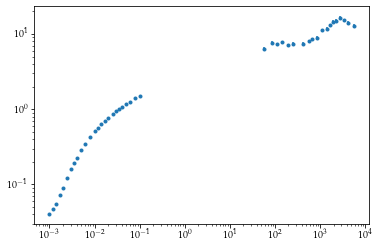

In [10]:
error = swarms[0].datasets[0].data[:,1][...,None]
DTmu = np.append( swarms[0].datasets[0].data, error*0.05, axis=1 )

filename = '../swarm/DTmu.%s.txt' % refs[0]
np.savetxt(filename,DTmu,fmt='%.15E',delimiter=' ')

temp = swarms[4].datasets[0].data
temp[:,2] *= 0.01*temp[:,1]

filename = '../swarm/DTmu.%s.txt' % refs[4]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

DTmu = np.append( DTmu, temp, axis=0)

plt.figure(1)
plt.errorbar(DTmu[:,0],DTmu[:,1],yerr=DTmu[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

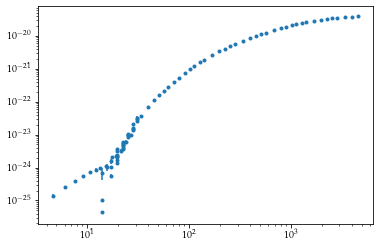

In [11]:
T = 273.15
temp = np.copy(swarms[1].datasets[0].data)
temp[:,0] *= 100. / 133.322 * kB * T * Td
temp[:,1] *= 100. / 133.322 * kB * T
error = temp[:,1][...,None] * 0.10
ion = np.append( temp, error, axis=1 )

filename = '../swarm/aion.%s.txt' % refs[1]
np.savetxt(filename,ion,fmt='%.15E',delimiter=' ')

T = 273.15
temp = np.copy(swarms[2].datasets[0].data)
temp[:,0] *= 100. / 133.322 * kB * T
temp[:,1] *= temp[:,0] 
temp[:,2] *= temp[:,0]
temp[:,0] *= Td
# ion = temp
ion = np.append( ion, temp, axis=0)

filename = '../swarm/aion.%s.txt' % refs[2]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-2].datasets[0].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4 
temp[:,2] *= 1e-4
# ion = temp
ion = np.append( ion, temp, axis=0)

filename = '../swarm/aion.%s.txt' % refs[-2]
np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(ion[:,0],ion[:,1],yerr=ion[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')
# plt.xlim([1e1, 1e4])
# plt.ylim([5e-25, 8e-20])

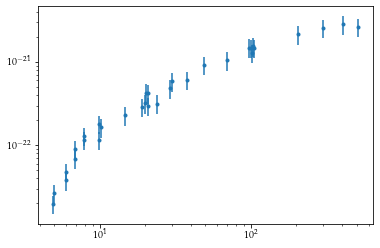

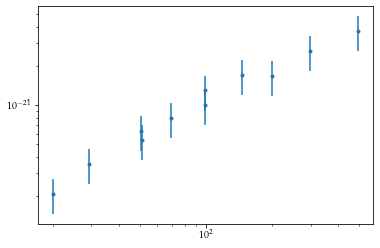

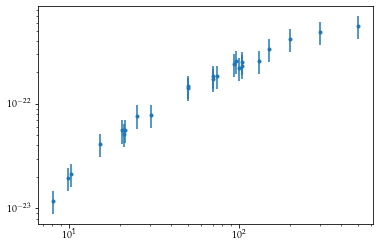

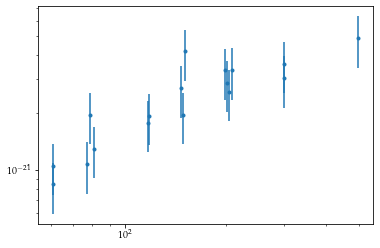

In [12]:
temp = np.copy(swarms[-1].datasets[0].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.25
a1 = np.append( temp, error, axis=1 )

filename = '../swarm/aex1.%s.txt' % refs[-1]
np.savetxt(filename,a1,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-1].datasets[1].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.3
a2 = np.append( temp, error, axis=1 )

filename = '../swarm/aex2.%s.txt' % refs[-1]
np.savetxt(filename,a2,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-1].datasets[2].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.25
a3 = np.append( temp, error, axis=1 )

filename = '../swarm/aex3.%s.txt' % refs[-1]
np.savetxt(filename,a3,fmt='%.15E',delimiter=' ')

temp = np.copy(swarms[-1].datasets[3].data)
temp[:,0] *= 1e-4 * Td
temp[:,1] *= 1e-4
error = temp[:,1][...,None] * 0.3
a4 = np.append( temp, error, axis=1 )

filename = '../swarm/aex4.%s.txt' % refs[-1]
np.savetxt(filename,a4,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(a1[:,0],a1[:,1],yerr=a1[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

plt.figure(2)
plt.errorbar(a2[:,0],a2[:,1],yerr=a2[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

plt.figure(3)
plt.errorbar(a3[:,0],a3[:,1],yerr=a3[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

plt.figure(4)
plt.errorbar(a4[:,0],a4[:,1],yerr=a4[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')
